# Analisis Biaya Pengiriman, Subsidi, dan Risiko Pembatalan Transaksi E-Commerce Indonesia


## Latar Belakang dan Tujuan
Dataset ini dipakai untuk menjawab tiga pertanyaan inti operasional:
- Bagaimana struktur biaya pengiriman saat ini?
- Seberapa besar peran subsidi ongkir dalam transaksi?
- Segmen mana yang punya risiko pembatalan paling tinggi?

Analisis difokuskan pada segmentasi wilayah, metode pembayaran, dan kategori produk. Karena kolom waktu belum lengkap, pembahasan tidak berfokus pada tren waktu, melainkan pada pola struktural operasional.


In [1]:
#Import library
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

In [2]:
# Setting tampilan
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

# Setting gaya visual
sns.set_theme(style="whitegrid")

---
## 1. Data Understanding
Di bagian ini kita cek fondasi data dulu: ukuran dataset, tipe data, missing value, dan statistik awal.


### Load Dataset

In [3]:

url = "https://raw.githubusercontent.com/AlvitoDwiP/operasional_ecommers_indo/refs/heads/main/data/raw/all_months_clean.csv"
df = pd.read_csv(
    url,
    sep=";",               
    encoding="utf-8-sig",  
    engine="python"
)

print("Shape:", df.shape)
df.head()


Shape: (20848, 19)


,order_id,total_qty,total_weight_gr,total_returned_qty,Total Diskon,product_categories,num_product_categories,Status Pesanan,Alasan Pembatalan,Opsi Pengiriman,Metode Pembayaran,Kota/Kabupaten,Provinsi,Ongkos Kirim Dibayar oleh Pembeli,Estimasi Potongan Biaya Pengiriman,Total Pembayaran,Perkiraan Ongkos Kirim,Waktu Pesanan Dibuat,source_file
0,ORD_0000001,2,2000,0,0,Celengan,1,Selesai,NaN,Reguler (Cashless)-SPX Standard,Saldo ShopeePay,KOTA SERANG,BANTEN,0,10000,38300,10000,2024-04-01 00:15,AprilSales2024.xlsx
1,ORD_0000002,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA SEMARANG,JAWA TENGAH,0,14500,18576,14500,2024-04-01 01:47,AprilSales2024.xlsx
2,ORD_0000003,1,500,0,0,Celengan,1,Selesai,NaN,Hemat Kargo-SPX Hemat,SeaBank Bayar Instan,KAB. BOGOR,JAWA BARAT,0,8000,7069,8000,2024-04-01 04:25,AprilSales2024.xlsx
3,ORD_0000004,2,400,0,0,Mangkok Sambal / Saus,1,Selesai,NaN,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA JAMBI,JAMBI,0,20000,32200,20000,2024-04-01 04:41,AprilSales2024.xlsx
4,ORD_0000005,3,3600,0,0,"Keranjang, Other, Tempat Nasi",3,Batal,Dibatalkan oleh Pembeli. Alasan: Ubah Pesanan ...,Hemat Kargo-SPX Hemat,COD (Bayar di Tempat),KOTA TANGERANG,BANTEN,0,0,0,8000,2024-04-01 06:12,AprilSales2024.xlsx


**Insight awal**
Dataset berisi **20.848 baris** dan **19 kolom** pada level order, jadi granularity datanya sudah tepat untuk analisis operasional per transaksi.


### Cek struktur kolom, tipe data, missing values, dan ringkasan statistik awal

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20848 entries, 0 to 20847
Data columns (total 19 columns):
 #   Column                              Non-Null Count  Dtype 
---  ------                              --------------  ----- 
 0   order_id                            20848 non-null  object
 1   total_qty                           20848 non-null  int64 
 2   total_weight_gr                     20848 non-null  int64 
 3   total_returned_qty                  20848 non-null  int64 
 4   Total Diskon                        20848 non-null  int64 
 5   product_categories                  20848 non-null  object
 6   num_product_categories              20848 non-null  int64 
 7   Status Pesanan                      20848 non-null  object
 8   Alasan Pembatalan                   2830 non-null   object
 9   Opsi Pengiriman                     20848 non-null  object
 10  Metode Pembayaran                   20848 non-null  object
 11  Kota/Kabupaten                      20848 non-null  ob

**Interpretasi `df.info()`**
Struktur data sudah cukup rapi: kolom numerik utama terbaca sebagai angka, dan mayoritas kolom terisi penuh. Catatan pentingnya ada dua: `Alasan Pembatalan` memang banyak kosong (hanya relevan untuk order batal), dan `Waktu Pesanan Dibuat` masih bertipe `object` serta belum lengkap.


#### **Cek Missing values**

In [5]:
missing = df.isna().sum().sort_values(ascending=False).to_frame("Missing Count")
missing["Missing (%)"] = (missing["Missing Count"] / len(df) * 100).round(2)
missing.head(10)


,Missing Count,Missing (%)
Alasan Pembatalan,18018,86.43
Waktu Pesanan Dibuat,1980,9.50
order_id,0,0.00
Metode Pembayaran,0,0.00
Perkiraan Ongkos Kirim,0,0.00
Total Pembayaran,0,0.00
Estimasi Potongan Biaya Pengiriman,0,0.00
Ongkos Kirim Dibayar oleh Pembeli,0,0.00
Provinsi,0,0.00
Kota/Kabupaten,0,0.00


**Interpretasi missing value**

Missing terbesar ada di `Alasan Pembatalan` (**18.018 baris / 86,43%**) dan `Waktu Pesanan Dibuat` (**1.980 baris / 9,50%**). Untuk proyek ini, fokus analisis diarahkan ke efisiensi biaya dan risiko pembatalan lintas segmen, bukan analisis tren waktu.


#### **Statistik deskriptif numerik**

In [6]:
df.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
total_qty,20848.0,2.560821,7.796763,1.0,1.0,1.0,2.0,256.0
total_weight_gr,20848.0,2004.529691,7106.357515,10.0,300.0,500.0,1600.0,375000.0
total_returned_qty,20848.0,0.017748,0.548656,0.0,0.0,0.0,0.0,70.0
Total Diskon,20848.0,405.199348,9784.017705,0.0,0.0,0.0,0.0,700000.0
num_product_categories,20848.0,1.112097,0.485361,1.0,1.0,1.0,1.0,11.0
Ongkos Kirim Dibayar oleh Pembeli,20848.0,4189.990695,13578.489678,0.0,0.0,0.0,3000.0,584000.0
Estimasi Potongan Biaya Pengiriman,20848.0,10722.539284,12672.471066,0.0,0.0,9500.0,15000.0,312000.0
Total Pembayaran,20848.0,50683.597036,144019.263221,0.0,13480.0,21800.0,41600.0,3403591.0
Perkiraan Ongkos Kirim,20848.0,18425.626343,23791.508665,1.0,8000.0,11000.0,20000.0,959200.0


**Interpretasi statistik numerik**
Tidak terlihat nilai negatif pada metrik utama (qty, berat, ongkir), jadi data lolos sanity check dasar. Namun ada nilai maksimum yang jauh lebih tinggi dari median, yang menandakan distribusi condong ke kanan dan perlu penanganan outlier saat visualisasi.


### Gambaran Operasional Cepat
Sebelum masuk ke preprocessing, kita petakan kondisi bisnis secara ringkas lewat empat sudut pandang: status pesanan, cancellation rate, top provinsi, dan metode pembayaran.


#### A) Distribusi status pesanan

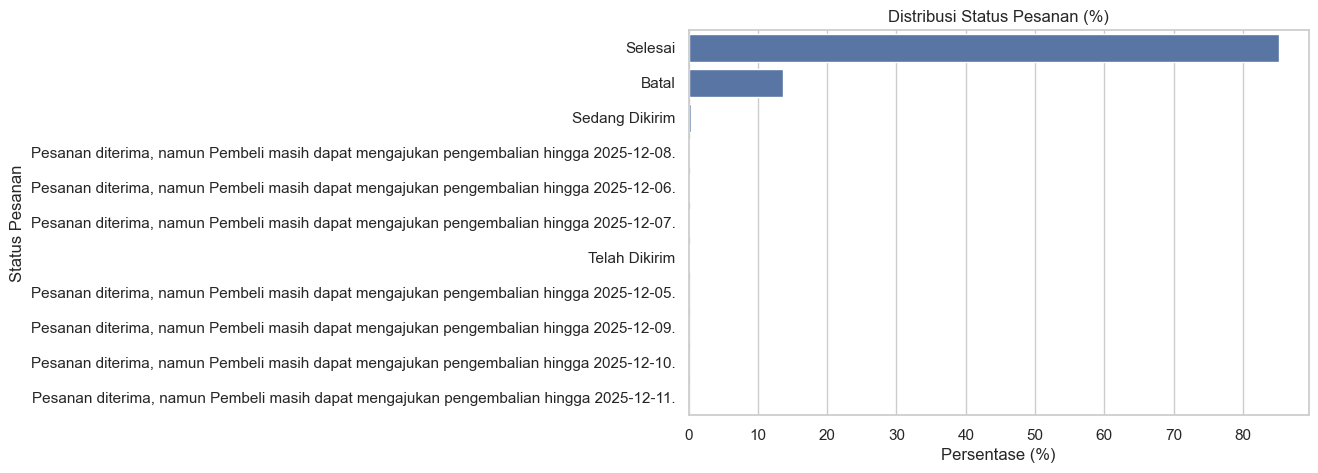

In [7]:
status_dist = df["Status Pesanan"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
sns.barplot(x=status_dist.values, y=status_dist.index)
plt.title("Distribusi Status Pesanan (%)")
plt.xlabel("Persentase (%)")
plt.ylabel("Status Pesanan")
plt.show()



**Insight distribusi status**
Dari grafik status pesanan, porsi order selesai masih dominan, tetapi order batal tetap terlihat signifikan. Ini menguatkan bahwa analisis biaya dan pembatalan perlu dilanjutkan di level segmen agar akar masalahnya lebih jelas.


#### B) Tingkat Pembatalan Keseluruhan

In [8]:
df["cancel_flag"] = np.where(
    df["Status Pesanan"].str.lower() == "batal", 1, 0
)

cancel_rate = df["cancel_flag"].mean() * 100
print(f"Cancellation Rate: {cancel_rate:.2f}%")


Cancellation Rate: 13.57%


**Insight cancellation rate**
Output menunjukkan **cancellation rate = 13,57%**. Artinya, dari 100 order, sekitar 14 order batal. Angka ini cukup material untuk operasional karena bisa memicu biaya logistik tidak produktif dan subsidi yang tidak menghasilkan transaksi selesai.


#### C) Top 10 Provinsi Berdasarkan Jumlah Order

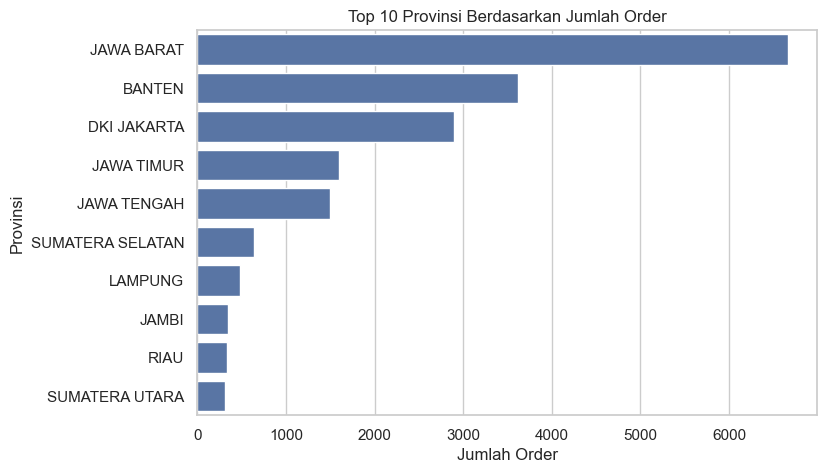

In [9]:
top_province = (
    df["Provinsi"]
    .value_counts()
    .head(10)
)

plt.figure(figsize=(8,5))
sns.barplot(x=top_province.values, y=top_province.index)
plt.title("Top 10 Provinsi Berdasarkan Jumlah Order")
plt.xlabel("Jumlah Order")
plt.show()


**Insight top provinsi**
Grafik top 10 provinsi membantu menentukan prioritas analisis. Provinsi dengan volume order besar perlu dipantau lebih ketat karena perubahan kecil pada biaya atau pembatalan di segmen ini dampaknya langsung besar ke total performa bisnis.


#### D) Distribusi Metode Pembayaran

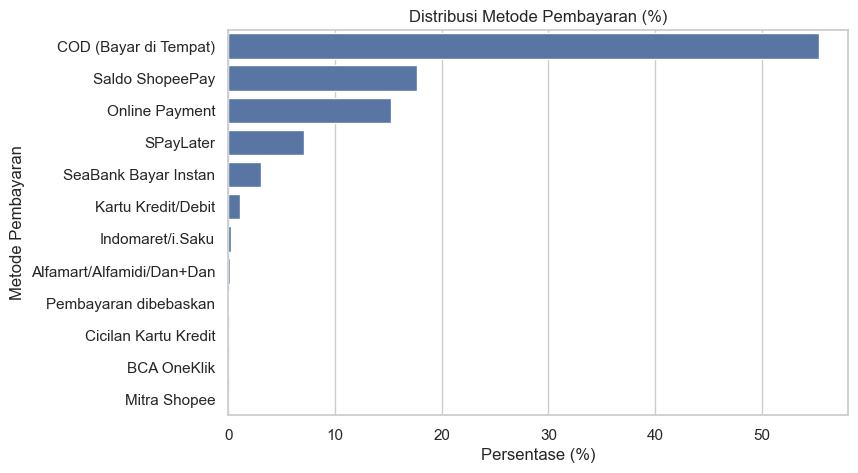

In [10]:
payment_dist = df["Metode Pembayaran"].value_counts(normalize=True) * 100

plt.figure(figsize=(8,5))
sns.barplot(x=payment_dist.values, y=payment_dist.index)
plt.title("Distribusi Metode Pembayaran (%)")
plt.xlabel("Persentase (%)")
plt.ylabel("Metode Pembayaran")
plt.show()


**Insight metode pembayaran**
Distribusi metode pembayaran menunjukkan kanal transaksi yang paling sering dipakai pelanggan. Metode yang dominan nantinya perlu dibandingkan dengan cancellation rate agar terlihat apakah ada kanal pembayaran yang berisiko lebih tinggi.


### Ringkasan Data Understanding
Tahap awal ini memberi tiga pijakan utama: tingkat pembatalan total sudah terukur, segmen wilayah prioritas sudah terlihat, dan preferensi metode pembayaran sudah terpetakan. Ini menjadi dasar untuk preprocessing dan feature engineering di tahap berikutnya.


## 2. Data Preprocessing dan Feature Engineering
Tujuan tahap ini adalah membuat dataset lebih konsisten dan siap dipakai untuk analisis inti. Langkah utamanya: rapikan kolom, buat indikator pembatalan, turunkan metrik biaya logistik, pisahkan transaksi free shipping, lalu siapkan dataset akhir untuk analisis lanjutan.


### Hapus Kolom Non-Analitis
Kolom `source_file` dihapus karena hanya metadata asal file dan tidak menambah nilai analitis untuk evaluasi operasional.


In [11]:
df = df.drop(columns=["source_file"], errors="ignore")

df.columns


Index(['order_id', 'total_qty', 'total_weight_gr', 'total_returned_qty', 'Total Diskon', 'product_categories', 'num_product_categories', 'Status Pesanan', 'Alasan Pembatalan', 'Opsi Pengiriman',
       'Metode Pembayaran', 'Kota/Kabupaten', 'Provinsi', 'Ongkos Kirim Dibayar oleh Pembeli', 'Estimasi Potongan Biaya Pengiriman', 'Total Pembayaran', 'Perkiraan Ongkos Kirim',
       'Waktu Pesanan Dibuat', 'cancel_flag'],
      dtype='object')

### Standarisasi Nama Kolom
Nama kolom diseragamkan ke format lowercase + underscore supaya kode analisis lebih konsisten, lebih aman dari typo, dan mudah dibaca ulang.


In [12]:
rename_map = {
    "Total Diskon": "total_diskon",
    "Status Pesanan": "status_pesanan",
    "Alasan Pembatalan": "alasan_pembatalan",
    "Opsi Pengiriman": "opsi_pengiriman",
    "Metode Pembayaran": "metode_pembayaran",
    "Kota/Kabupaten": "kota_kabupaten",
    "Provinsi": "provinsi",
    "Ongkos Kirim Dibayar oleh Pembeli": "ongkir_dibayar",
    "Estimasi Potongan Biaya Pengiriman": "subsidi_ongkir",
    "Total Pembayaran": "total_pembayaran",
    "Perkiraan Ongkos Kirim": "perkiraan_ongkir",
    "total_weight_gr": "total_berat_gr"
}

df = df.rename(columns=rename_map)
df.columns


Index(['order_id', 'total_qty', 'total_berat_gr', 'total_returned_qty', 'total_diskon', 'product_categories', 'num_product_categories', 'status_pesanan', 'alasan_pembatalan', 'opsi_pengiriman',
       'metode_pembayaran', 'kota_kabupaten', 'provinsi', 'ongkir_dibayar', 'subsidi_ongkir', 'total_pembayaran', 'perkiraan_ongkir', 'Waktu Pesanan Dibuat', 'cancel_flag'],
      dtype='object')

### Buat `cancel_flag`
Dibuat variabel biner untuk status pembatalan:
- `1` = batal
- `0` = tidak batal

Kolom ini akan dipakai sebagai indikator risiko utama pada analisis segmen.


In [13]:
df["cancel_flag"] = np.where(
    df["status_pesanan"].str.lower() == "batal",
    1,
    0
)

df["cancel_flag"].mean()


np.float64(0.13574443591711435)

**Interpretasi `cancel_flag`**
Rata-rata `cancel_flag` = **0,1357**, konsisten dengan cancellation rate **13,57%**. Artinya definisi flag sudah benar dan siap dipakai untuk agregasi per wilayah atau metode pembayaran.


### Konversi Berat ke Kilogram
`total_berat_gr` dikonversi ke `total_berat_kg` agar metrik biaya per kilogram lebih mudah diinterpretasikan dalam konteks logistik.


In [14]:
df["total_berat_kg"] = df["total_berat_gr"] / 1000

df[["total_berat_gr", "total_berat_kg"]].head()


,total_berat_gr,total_berat_kg
0,2000,2.0
1,500,0.5
2,500,0.5
3,400,0.4
4,3600,3.6


**Interpretasi konversi berat**
Hasil sample konversi menunjukkan nilai gram ke kilogram sudah sesuai (misalnya 2000 gr menjadi 2,0 kg), jadi kolom turunan valid untuk perhitungan lanjutan.


### Hitung `ongkir_per_kg`
Metrik `ongkir_per_kg` dibuat untuk melihat efisiensi biaya pengiriman dengan membandingkan ongkir aktual terhadap berat kiriman.


In [15]:
df["ongkir_per_kg"] = np.where(
    df["total_berat_kg"] > 0,
    df["ongkir_dibayar"] / df["total_berat_kg"],
    np.nan
)

df["ongkir_per_kg"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


count     20848.000000
mean       6478.887448
std       24408.963300
min           0.000000
25%           0.000000
50%           0.000000
75%        1978.245028
90%       16000.000000
95%       35000.000000
99%       97500.000000
max      800000.000000
Name: ongkir_per_kg, dtype: float64

**Interpretasi `ongkir_per_kg`**
Distribusi `ongkir_per_kg` sangat skewed: median = **0**, sementara mean sekitar **6.479** dan maksimum sangat tinggi. Pola ini menandakan banyak transaksi tidak membayar ongkir langsung (free shipping), sehingga analisis biaya aktual perlu dipisahkan dari transaksi gratis ongkir.


### Identifikasi Transaksi Free Shipping
Buat indikator `free_shipping_flag` untuk memisahkan transaksi ongkir 0 dari transaksi berbayar.


In [16]:
df["free_shipping_flag"] = np.where(df["ongkir_dibayar"] == 0, 1, 0)

(df["free_shipping_flag"].mean() * 100)


np.float64(69.80046047582502)

**Interpretasi free shipping**
Persentase free shipping mencapai **69,80%**. Jadi mayoritas order tidak membayar ongkir langsung, dan ini berpotensi menutupi pola biaya aktual jika tidak dipisahkan saat analisis.


### Bentuk Dataset Transaksi Berbayar (`df_paid`)
Untuk membaca biaya logistik yang benar-benar dibayar pelanggan, dibuat subset `df_paid` dengan syarat `ongkir_dibayar > 0`.


In [17]:
df_paid = df[df["ongkir_dibayar"] > 0].copy()

df_paid["ongkir_per_kg"].describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99])


count      6296.000000
mean      21453.596809
std       40642.044674
min           0.227273
25%        3137.254902
50%       10000.000000
75%       22500.000000
90%       50000.000000
95%       80000.000000
99%      170093.750000
max      800000.000000
Name: ongkir_per_kg, dtype: float64

**Interpretasi `df_paid`**
Subset berbayar berisi **6.296 transaksi**. Pada subset ini, median `ongkir_per_kg` sekitar **10.000**, sehingga lebih representatif untuk evaluasi efisiensi biaya dibanding dataset campuran (gratis + berbayar).


### Tangani Outlier untuk Visualisasi
Nilai ekstrem pada `ongkir_per_kg` di-clip di persentil ke-99 agar grafik lebih terbaca tanpa mengubah data mentah utama.


In [18]:
upper_cap = df_paid["ongkir_per_kg"].quantile(0.99)

df_paid["ongkir_per_kg_clipped"] = np.where(
    df_paid["ongkir_per_kg"] > upper_cap,
    upper_cap,
    df_paid["ongkir_per_kg"]
)

df_paid["ongkir_per_kg_clipped"].describe()


count      6296.000000
mean      20114.545645
std       28917.210029
min           0.227273
25%        3137.254902
50%       10000.000000
75%       22500.000000
max      170093.750000
Name: ongkir_per_kg_clipped, dtype: float64

**Interpretasi clipping**
Setelah clipping, nilai maksimum visualisasi berada di kisaran **170.093,75**. Ini membantu grafik lebih stabil dibaca sambil tetap mempertahankan karakter distribusi biaya pada transaksi berbayar.


### Ekspor Dataset Hasil Preprocessing
Dataset final diekspor untuk dipakai di notebook analisis berikutnya.


In [19]:
from pathlib import Path

out_dir = Path("/Users/a/Documents/operasional_ecommers_indo/data/process")
out_dir.mkdir(parents=True, exist_ok=True)

f1 = out_dir / "dataset_preprocessed_full.csv"
f2 = out_dir / "dataset_preprocessed_paid_shipping.csv"

print("shape df:", df.shape)
print("shape df_paid:", df_paid.shape)

df.to_csv(f1, index=False)
df_paid.to_csv(f2, index=False)

print("exists f1:", f1.exists(), "size:", f1.stat().st_size if f1.exists() else None)
print("exists f2:", f2.exists(), "size:", f2.stat().st_size if f2.exists() else None)
print("isi folder:", [p.name for p in out_dir.glob("*.csv")])


shape df: (20848, 22)
shape df_paid: (6296, 23)
exists f1: True size: 3701350
exists f2: True size: 1189928
isi folder: ['dataset_preprocessed_full.csv', 'dataset_preprocessed_paid_shipping.csv']


Dua file yang disiapkan:
- `dataset_preprocessed_full.csv` (seluruh transaksi)
- `dataset_preprocessed_paid_shipping.csv` (khusus transaksi ongkir berbayar)

Pastikan path ekspor disesuaikan dengan environment yang dipakai (lokal Jupyter vs Colab).
